Columns:
 Index(['Age', 'EducationYears', 'HoursPerWeek', 'Experience', 'Income'], dtype='object')

Target distribution:
 Income
0    80
1    40
Name: count, dtype: int64
Accuracy with 10 trees: 1.0
Accuracy with 50 trees: 1.0
Accuracy with 100 trees: 1.0
Accuracy with 150 trees: 1.0


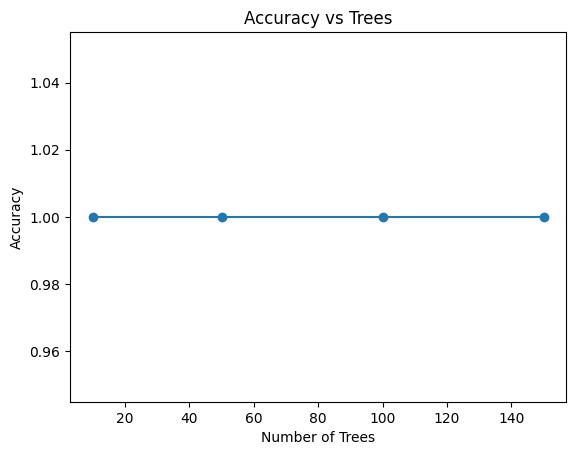


Final Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00         8

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



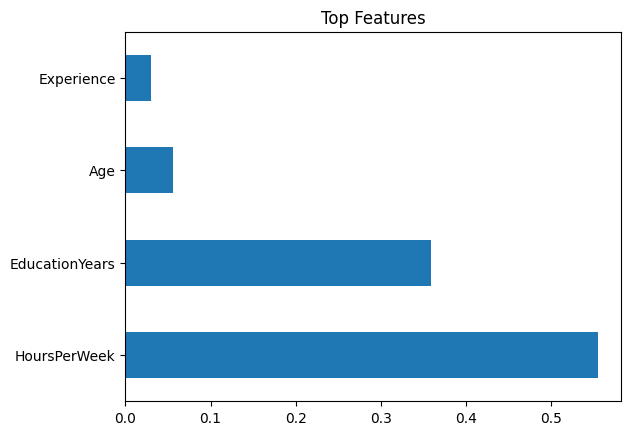

In [ ]:
# Name: Navithanjali
# Roll No: 24BAD077
# Scenario 3 - Random Forest (FINAL FIX)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ------------------ Load Dataset ------------------
data = pd.read_csv("income_random_forest.csv")

# Clean column names
data.columns = data.columns.str.strip()

print("Columns:\n", data.columns)

# ------------------ Target Handling FIRST ------------------
# Convert Income to 0/1 BEFORE get_dummies

data['Income'] = data['Income'].astype(str).str.strip()

data['Income'] = data['Income'].replace({
    '<=50K': 0, '>50K': 1,
    '<=50K.': 0, '>50K.': 1
})

# ------------------ Features & Target ------------------
X = data.drop("Income", axis=1)
y = data["Income"]

# ------------------ Convert categorical features ------------------
X = pd.get_dummies(X, drop_first=True)

print("\nTarget distribution:\n", y.value_counts())

# ------------------ Train Test Split ------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------ Tune Trees ------------------
trees = [10, 50, 100, 150]
acc = []

for t in trees:
    rf = RandomForestClassifier(n_estimators=t, random_state=42)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    score = accuracy_score(y_test, pred)
    acc.append(score)
    print(f"Accuracy with {t} trees:", score)

# ------------------ Graph ------------------
plt.plot(trees, acc, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Trees")
plt.show()

# ------------------ Final Model ------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("\nFinal Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ------------------ Feature Importance ------------------
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top Features")
plt.show()